# Regresión Lineal LASSO - RIDGE - Tasación vivienda

### Objetivo

Entrenar modelos de **Regresión Lineal, Ridge y Lasso** para predecir el precio de viviendas en Vigo, encontrar el nivel óptimo de regularización mediante validación cruzada y comparar su capacidad de generalización.

### Contexto de negocio

**El cliente:** una inmobiliaria que opera en el mercado residencial de Vigo.

**El problema:** estimar el precio de una vivienda a partir de sus características. La superficie, habitaciones, baños, antigüedad, distancia al centro y garaje pueden influir en el valor final. ¿Podemos utilizar estas variables para construir un modelo de valoración fiable y comprobar si la regularización mejora las predicciones?


### Lasso y Ridge
- Funciona muy bien cuando son muchas variables y hay alguna muy correlacionada

#### El problema que resuelven
- *Imagina que estás construyendo un modelo de regresión lineal para predecir, por ejemplo, el CLV (Customer Lifetime Value) de un cliente a partir de 40 variables: edad, gasto medio, frecuencia de compra, canal de adquisición, etc.*
- *Con tantas variables, la regresión lineal clásica tiende a sobreajustar (overfitting): encuentra coeficientes muy grandes que se ajustan perfectamente a tus datos históricos pero fallan al predecir clientes nuevos. El modelo "memoriza" ruido en lugar de aprender el patrón real.*
- *Ridge y Lasso resuelven esto añadiendo una penalización a los coeficientes grandes durante el entrenamiento. Es como decirle al modelo: "ajústate bien a los datos, pero no te vuelvas loco con los coeficientes".*

#### La diferencia en una frase
- Ridge reduce el peso de todas las variables por igual. 
- Lasso decide qué variables sobran y las descarta.

### Ridge (penalización L2)

- **¿Qué hace?** Ridge castiga la suma de los coeficientes al cuadrado. El efecto: encoge todos los coeficientes hacia cero, pero nunca los deja exactamente en cero. Todas las variables se quedan en el modelo, solo que con menos peso.
- **¿Cuándo usarlo?** cuando crees que todas las variables aportan algo, aunque sea poco, y quieres estabilizar el modelo (por ejemplo, cuando hay variables muy correlacionadas entre sí, como "gasto mensual" y "gasto trimestral").
- **Importante**: se recomienda usar cuando tenemos muchas variables (20-30)

## Ejemplo - Se desea estimar el precio de la vivienda con las siguientes variables

## 1️. Setup: librerías y configuración visual

In [60]:
#Carga de librerias necesarias para realizar el ejercicio

# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# Métricas
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual
PURPLE = '#7a7bff'
GREEN  = '#6E7F5B'
RED    = '#C2412E'
GRAY   = '#F4EFE6'
INK    = '#2B2118'
MUTED  = '#bfbfbf'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [61]:
data = pd.read_excel("viviendas_vigo.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 200 | Columnas: 8


,id_vivienda,metros,habitaciones,baños,edad,distancia_centro,garaje,precio
0,1,45,1,1,15,10.0,1,175000
1,2,45,1,1,9,3.1,1,95000
2,3,45,1,1,30,10.2,0,150000
3,4,45,2,2,29,2.9,1,190000
4,5,48,1,1,41,1.8,0,95000


## 3. EDA: Análisis Exploratorio de datos

In [62]:
data.describe().round(2)

,id_vivienda,metros,habitaciones,baños,edad,distancia_centro,garaje,precio
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,100.50,116.79,3.34,2.18,25.54,5.62,0.64,362950.00
std,57.88,47.39,1.35,0.82,15.44,3.27,0.48,152987.17
min,1.00,45.00,1.00,1.00,1.00,1.10,0.00,95000.00
25%,50.75,81.00,2.00,2.00,13.75,3.20,0.00,245000.00
50%,100.50,110.00,3.00,2.00,22.50,4.60,1.00,337500.00
75%,150.25,140.25,4.00,3.00,34.25,7.35,1.00,441250.00
max,200.00,260.00,6.00,4.00,70.00,18.00,1.00,880000.00


In [63]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
id_vivienda,int64,0,0.0,200
metros,int64,0,0.0,108
habitaciones,int64,0,0.0,6
baños,int64,0,0.0,4
edad,int64,0,0.0,57
distancia_centro,float64,0,0.0,88
garaje,int64,0,0.0,2
precio,int64,0,0.0,93


In [64]:
data.head()

,id_vivienda,metros,habitaciones,baños,edad,distancia_centro,garaje,precio
0,1,45,1,1,15,10.0,1,175000
1,2,45,1,1,9,3.1,1,95000
2,3,45,1,1,30,10.2,0,150000
3,4,45,2,2,29,2.9,1,190000
4,5,48,1,1,41,1.8,0,95000


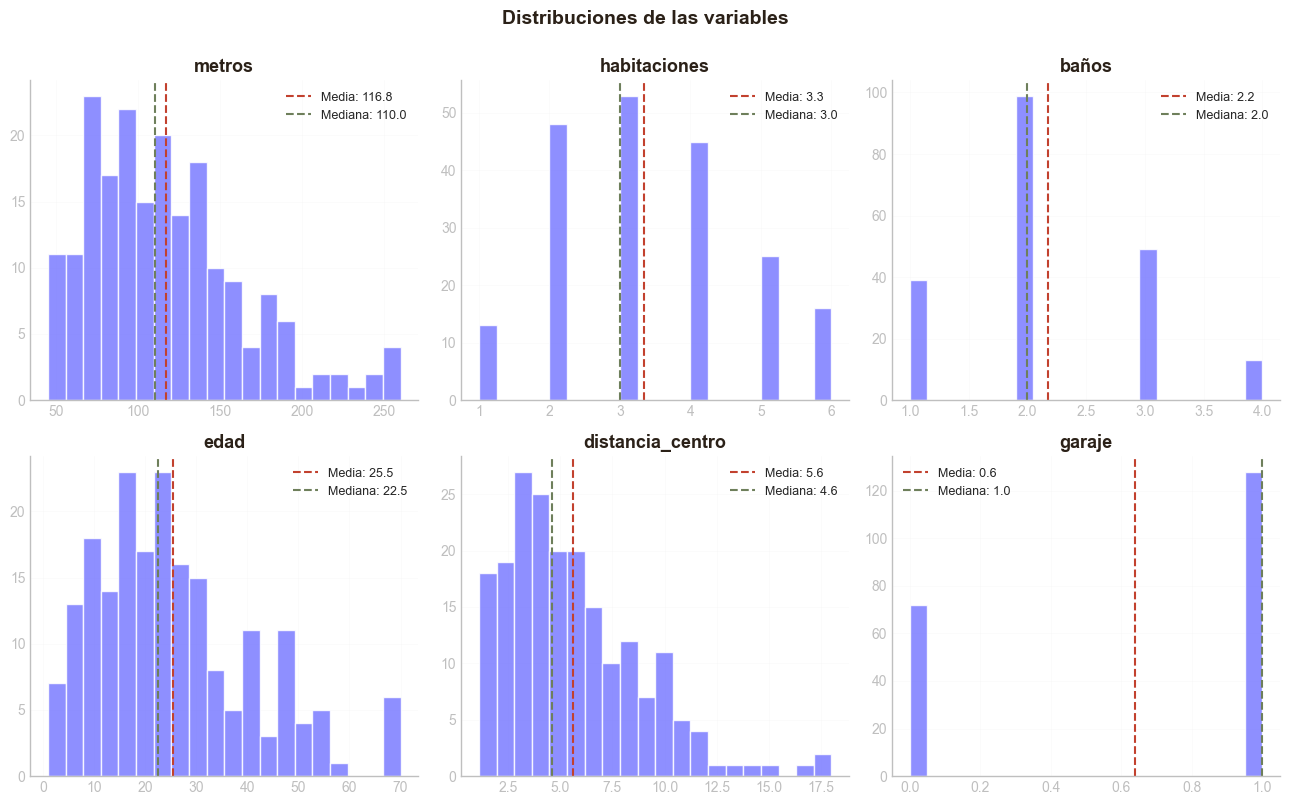

In [65]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["metros", "habitaciones", "baños", "edad", "distancia_centro", "garaje"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=GREEN, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

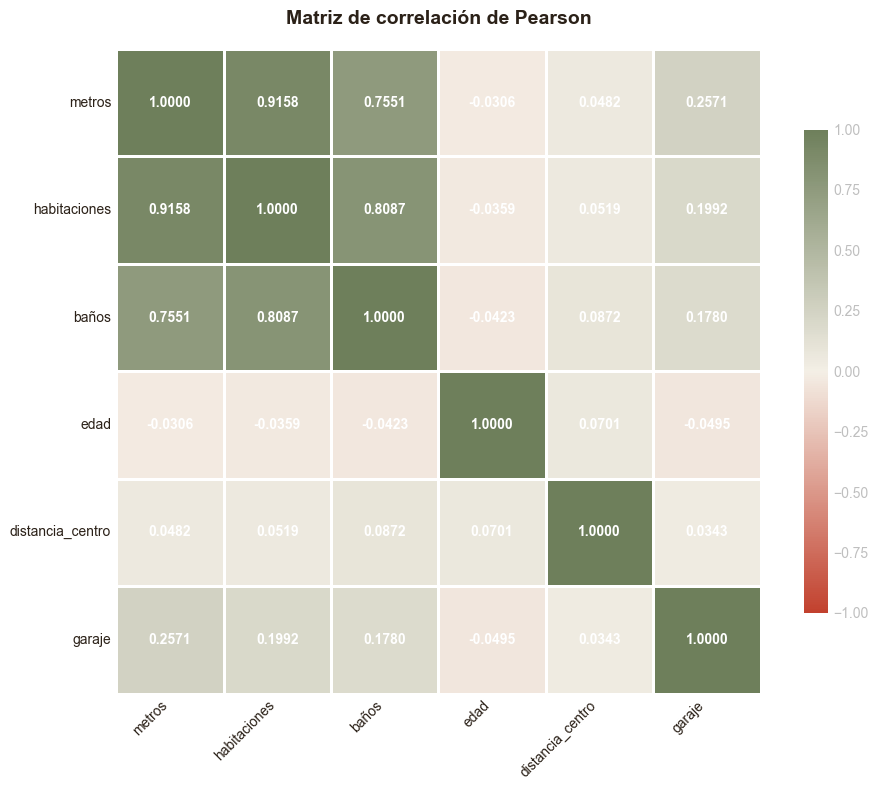

In [66]:
# Matriz de correlación

from matplotlib.colors import LinearSegmentedColormap

cols_num = ["metros", "habitaciones", "baños", "edad", "distancia_centro", "garaje"]

# Mapa de colores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_corr",
    [RED, GRAY, GREEN],
    N=256
)

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=cmap,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="white",
    cbar_kws={"shrink": 0.75},
    annot_kws={
        "size": 10,
        "weight": "bold",
        "color": "white"
    },
)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

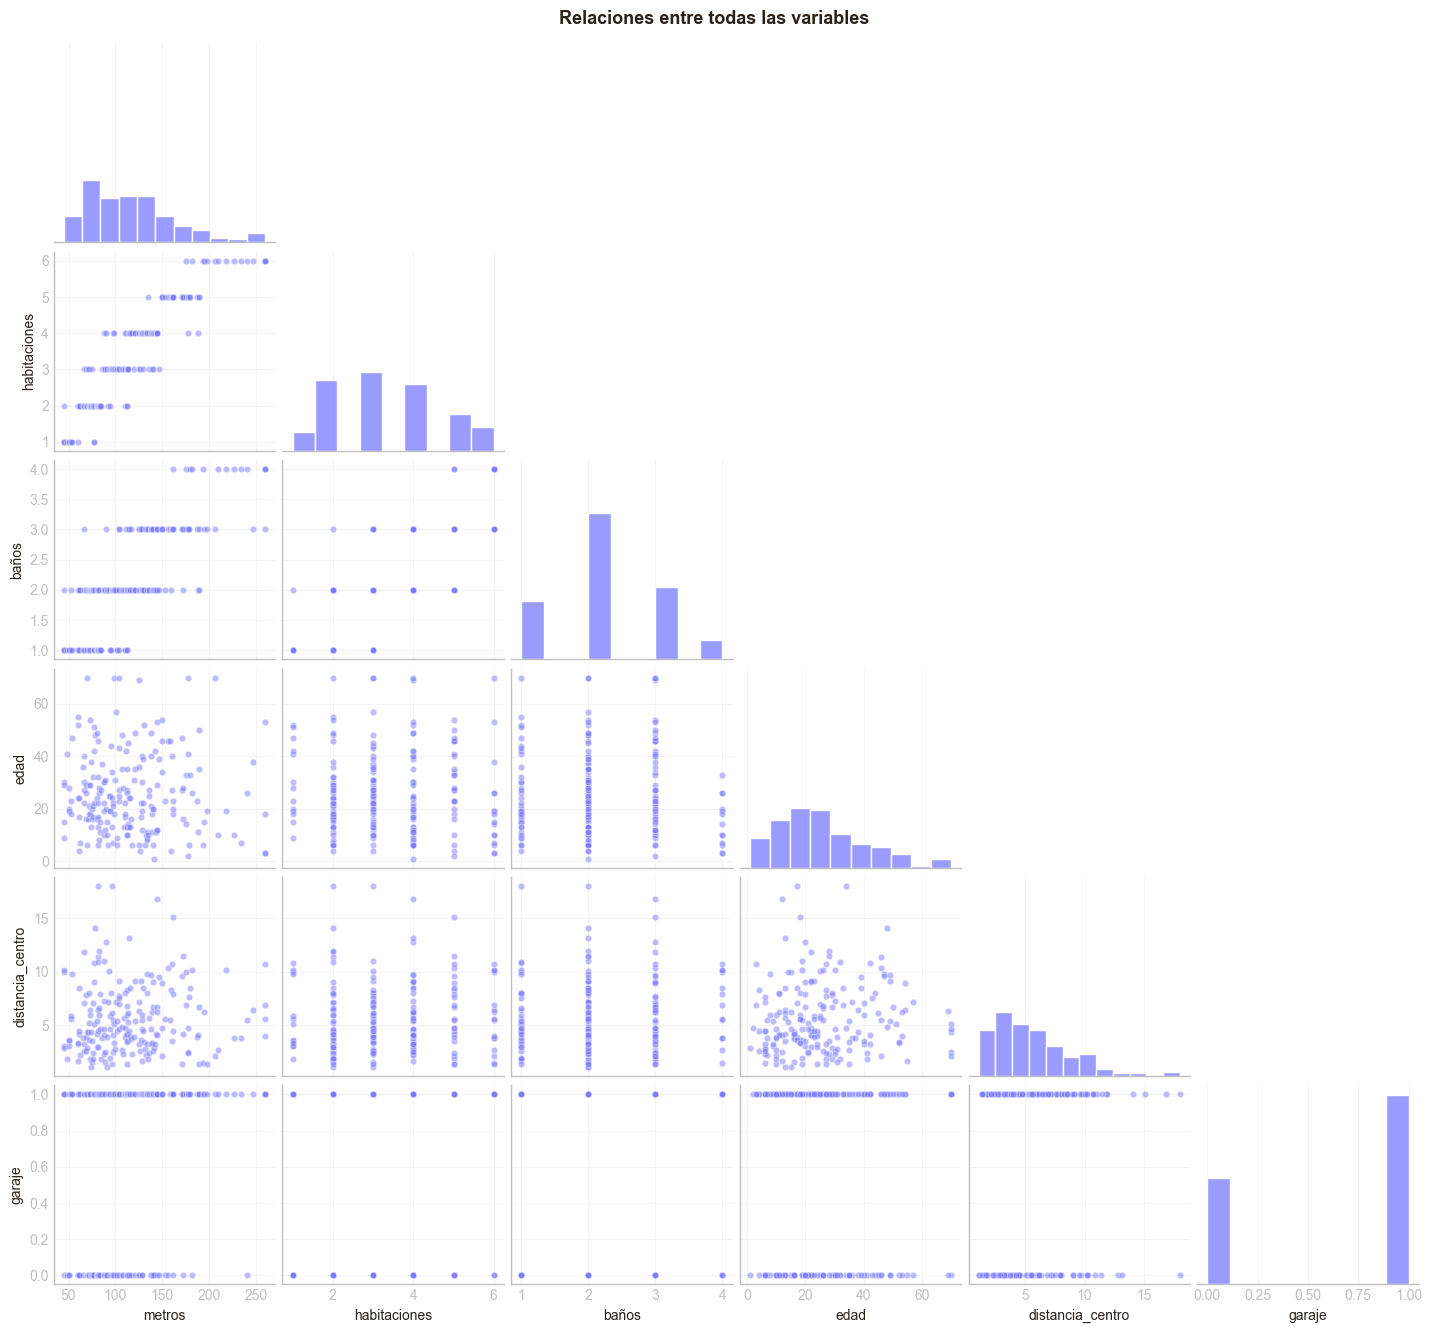

In [67]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split

In [68]:
# Definir los conjuntos de datos para las regresiones

X = data[cols_num]
y = data["precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [69]:
# Normalización 

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # aprende media/desv de train
X_test_scaled  = scaler.transform(X_test)        # aplica lo aprendido


## Modelo RIDGE


In [70]:
# Buscar el alpha óptimo para Ridge.
# Alpha controla la intensidad de la regularización:
# valores pequeños → parecido a Regresión Lineal
# valores grandes → mayor penalización de los coeficientes

from sklearn.linear_model import RidgeCV

# Valores de alpha que vamos a comparar
alphas = [0.001, 0.01, 0.05, 0.1, 1, 10, 100]

# Validación cruzada de 5 folds para elegir el mejor alpha
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5
)

# Entrenamiento con los datos escalados
ridge_cv.fit(X_train_scaled, y_train)

# Alpha con mejor rendimiento
print(f"Mejor valor de alpha: {ridge_cv.alpha_}")


Mejor valor de alpha: 1.0


In [87]:
# Entrenamos Ridge con el alpha óptimo encontrado mediante CV.

ridge = Ridge(alpha=1)

ridge.fit(
    X_train_scaled,
    y_train
)


,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [72]:
# Predicciones

pred_ridge = ridge.predict(X_test_scaled)

In [73]:
# Ver métricas

print("MAE:", mean_absolute_error(y_test, pred_ridge))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_ridge))
)

print(
    "R2:",
    r2_score(y_test, pred_ridge)
)

mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)

print(f"MAPE: {mape_ridge * 100:.2f}%")

MAE: 38238.654020889524
RMSE: 50229.895004712474
R2: 0.8665015262768865
MAPE: 11.39%


- **R²** = 0,867 — el modelo explica aproximadamente el **86,7% de la variabilidad del precio** de las viviendas. Es un buen ajuste, aunque todavía existe un 13,3% de variabilidad que el modelo no consigue explicar.

- **MAE** = 38.239 € — de media, el modelo se equivoca en unos **38.200 €** al predecir el precio de una vivienda. Es un error relevante, pero debe interpretarse teniendo en cuenta el rango de precios de las viviendas del dataset.

- **RMSE** = 50.230 € — es superior al MAE, como es habitual, porque el RMSE penaliza más los errores grandes. La diferencia indica que existen algunos errores de mayor magnitud, aunque no parecen ser extremadamente desproporcionados.

- **MAPE** = 11,39% — en términos de negocio, podemos decir que el modelo se desvía, en promedio, alrededor de un **11,4% respecto al precio real**. Por ejemplo, para una vivienda de **300.000 €**, supondría un error medio aproximado de **34.170 €**.

## Modelo Lasso 

### Lasso (penalización L1)

* **¿Qué hace?** Lasso castiga la suma de los valores absolutos de los coeficientes. El efecto: reduce los coeficientes hacia cero y puede hacer que algunos sean exactamente **0**, eliminando esas variables del modelo.
* **¿Cuándo usarlo?** cuando quieres identificar las variables más importantes y simplificar el modelo, especialmente cuando tienes muchas variables o variables que aportan poca información.
* **Importante**: es especialmente útil cuando tenemos muchas variables (20-30 o más) y queremos realizar una especie de **selección automática de variables**.


In [88]:
# Algoritmo para detectar el alpha

from sklearn.linear_model import LassoCV


# Validación cruzada de 5 folds
lasso_cv = LassoCV(
    cv=5,
    random_state=42
)

# Entrenamiento
lasso_cv.fit(X_train_scaled, y_train)

# Mejor valor de alpha encontrado
print(f"Mejor valor de alpha: {lasso_cv.alpha_}")

Mejor valor de alpha: 1551.5188322421102


In [89]:
lasso = Lasso(alpha= 1551.5188322421102)
lasso.fit(
    X_train_scaled,
    y_train
)

,alpha,1551.5188322421102
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [90]:
# Predicciones

pred_lasso = lasso.predict(X_test_scaled)

In [91]:
# Ver métricas

print("MAE:", mean_absolute_error(y_test, pred_lasso))

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_lasso))
)

print(
    "R2:",
    r2_score(y_test, pred_lasso)
)

mape_ridge = mean_absolute_percentage_error(y_test, pred_lasso)

print(f"MAPE: {mape_ridge * 100:.2f}%")

MAE: 36973.708884491614
RMSE: 48811.72566956652
R2: 0.8739333874518028
MAPE: 11.13%


- **R² = 0,874** — el modelo explica aproximadamente el **87,4% de la variabilidad del precio** de las viviendas. Es un buen ajuste y mejora ligeramente respecto a Ridge.

- **MAE = 36.974 €** — de media, el modelo se equivoca en unos **37.000 €** al predecir el precio de una vivienda. Es un error ligeramente inferior al obtenido con Ridge.

- **RMSE = 48.812 €** — es superior al MAE, como es normal, porque penaliza más los errores grandes. La diferencia indica que existen algunas viviendas en las que el modelo comete errores de mayor magnitud.

- **MAPE = 11,13%** — en términos de negocio, el modelo se desvía, en promedio, alrededor de un **11,1% respecto al precio real**. Por ejemplo, para una vivienda de **300.000 €**, supondría un error medio aproximado de **33.390 €**.


In [92]:
# Comparación de ambos modelos

# Comparación de métricas

resultados = pd.DataFrame({
    "Modelo": ["Ridge", "Lasso"],
    "MAE": [
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_test, pred_lasso))
    ],
    "MAPE (%)": [
        mean_absolute_percentage_error(y_test, pred_ridge) * 100,
        mean_absolute_percentage_error(y_test, pred_lasso) * 100
    ],
    "R2": [
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso)
    ]
})

print(resultados)

  Modelo           MAE          RMSE   MAPE (%)        R2
0  Ridge  38238.654021  50229.895005  11.394927  0.866502
1  Lasso  36973.708884  48811.725670  11.129411  0.873933


### Comparación de modelos

- **Ridge** obtiene un **R² de 0,867**, explicando aproximadamente el **86,7% de la variabilidad del precio**. Su error medio es de **38.239 € (MAE)** y **50.230 € (RMSE)**, con un **MAPE del 11,39%**.

- **Lasso** mejora ligeramente los resultados, con un **R² de 0,874** y unos errores inferiores: **36.974 € de MAE**, **48.812 € de RMSE** y **11,13% de MAPE**.

- **Lasso es el modelo que mejor funciona**, ya que consigue explicar algo más de variabilidad y reducir todos los errores de predicción respecto a Ridge. La diferencia es pequeña, pero Lasso ofrece el mejor resultado global en este conjunto de datos.

In [93]:
# Comparación de coeficientes

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coeficientes)

           Variable          Ridge          Lasso
0            metros  105969.798299  109430.024668
1      habitaciones   26993.781954   23552.504074
2             baños   12182.966530   11172.642761
3              edad  -28835.749009  -27656.688378
4  distancia_centro   -4979.177039   -3486.760557
5            garaje   12068.683097   10700.935044


### Comparación de coeficientes

- **Metros** es, con mucha diferencia, la variable con mayor peso en ambos modelos. Su coeficiente es de **105.970 € en Ridge** y **109.430 € en Lasso**, lo que confirma que la superficie es el factor con mayor influencia sobre el precio.

- **Edad** presenta un efecto negativo: las viviendas más antiguas tienden a tener un precio menor. Los coeficientes son de **-28.836 € en Ridge** y **-27.657 € en Lasso**.

- **Habitaciones** tienen un efecto positivo, con coeficientes de **26.994 € en Ridge** y **23.553 € en Lasso**. Lasso reduce ligeramente su peso respecto a Ridge.

- **Baños** también presentan una relación positiva con el precio, aunque con menor peso: **12.183 € en Ridge** frente a **11.173 € en Lasso**.

- **Garaje** tiene igualmente un efecto positivo, con **12.069 € en Ridge** y **10.701 € en Lasso**, indicando que disponer de garaje contribuye a incrementar el valor estimado de la vivienda.

- **Distancia al centro** presenta un efecto negativo. Cuanto mayor es la distancia, menor tiende a ser el precio. Ridge asigna **-4.979 €**, frente a **-3.487 € en Lasso**.

### Conclusión

Los dos modelos mantienen **los mismos signos en todas las variables**, por lo que ofrecen una interpretación similar. Lasso reduce el peso de la mayoría de las variables respecto a Ridge, aunque en este caso **ningún coeficiente llega a cero**, por lo que no elimina ninguna variable.

La variable claramente dominante es **metros**, seguida de **edad y habitaciones**. Por otro lado, **edad y distancia al centro** presentan una relación negativa con el precio.

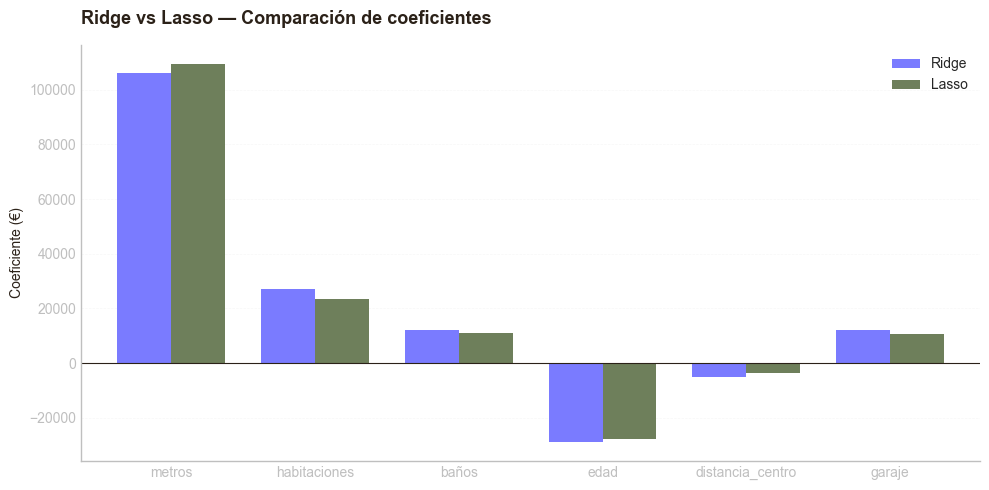

In [94]:
ax = coeficientes.set_index("Variable")[["Ridge", "Lasso"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=[PURPLE, GREEN],
    width=0.75
)

# Línea de referencia en 0
ax.axhline(0, color=INK, linewidth=0.8)

# Título y etiquetas
ax.set_title(
    "Ridge vs Lasso — Comparación de coeficientes",
    loc="left",
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Coeficiente (€)")

# Etiquetas del eje X
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)

# Grid únicamente horizontal
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)
ax.grid(axis="x", visible=False)

# Leyenda
ax.legend(
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

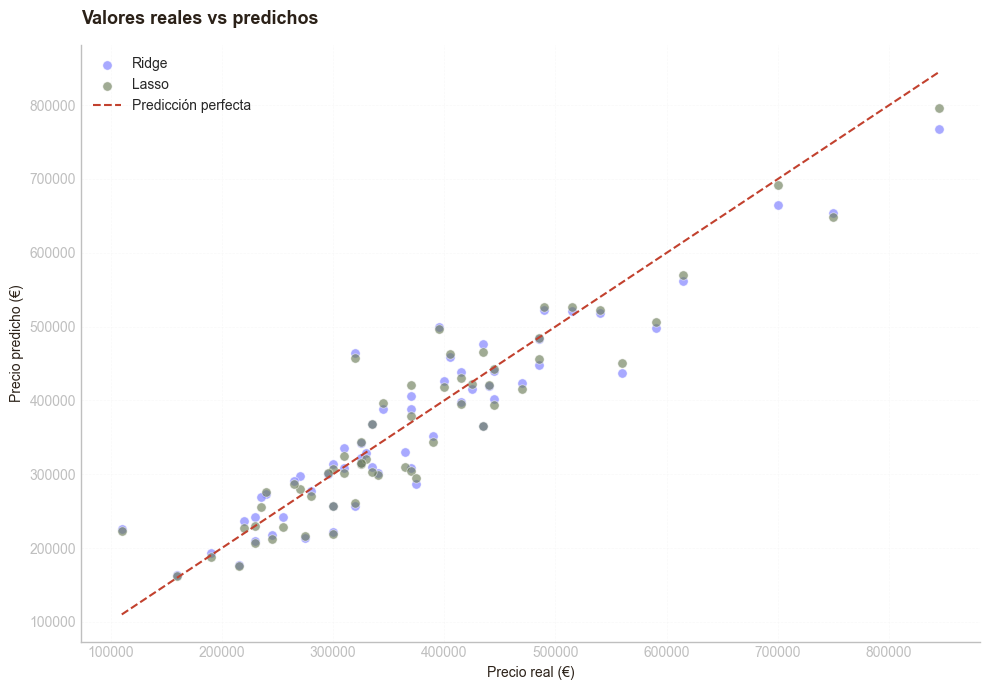

In [95]:
fig, ax = plt.subplots(figsize=(10, 7))

# Valores predichos
ax.scatter(
    y_test,
    pred_ridge,
    color=PURPLE,
    alpha=0.65,
    s=45,
    label="Ridge",
    edgecolors="white",
    linewidths=0.5
)

ax.scatter(
    y_test,
    pred_lasso,
    color=GREEN,
    alpha=0.65,
    s=45,
    label="Lasso",
    edgecolors="white",
    linewidths=0.5
)

# Línea de predicción perfecta
limites = [
    min(y_test.min(), pred_ridge.min(), pred_lasso.min()),
    max(y_test.max(), pred_ridge.max(), pred_lasso.max())
]

ax.plot(
    limites,
    limites,
    color=RED,
    linestyle="--",
    linewidth=1.5,
    label="Predicción perfecta"
)

# Título
ax.set_title(
    "Valores reales vs predichos",
    loc="left",
    pad=15
)

ax.set_xlabel("Precio real (€)")
ax.set_ylabel("Precio predicho (€)")

# Formato de ejes
ax.ticklabel_format(
    style="plain",
    axis="both"
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    alpha=0.4
)

# Leyenda
ax.legend(
    frameon=False,
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [96]:
#Búsqueda del alpha óptimo

#LassoCV prueba diferentes valores de alpha mediante validación cruzada de 5 folds
# y selecciona automáticamente el que obtiene mejor rendimiento.

#Después entrenamos Lasso con ese alpha y comprobamos sus métricas y cuántas variables 
# mantiene activas. Si un coeficiente queda exactamente en 0, Lasso elimina esa variable del modelo.

from sklearn.linear_model import LassoCV

# Rejilla amplia: si LassoCV eligiera el valor más bajo o más alto de la
# rejilla, sería señal de que el óptimo real cae fuera del rango probado.
alphas_lasso_cv = np.logspace(-2, 5.3, 60)

lasso_cv = LassoCV(alphas=alphas_lasso_cv, cv=5, max_iter=20000)
lasso_cv.fit(X_train_scaled, y_train)

print(f"Mejor alpha (Lasso): {lasso_cv.alpha_:,.1f}")

lasso_opt = Lasso(alpha=lasso_cv.alpha_, max_iter=20000)
lasso_opt.fit(X_train_scaled, y_train)

pred_lasso_opt = lasso_opt.predict(X_test_scaled)

print("\nLasso con alpha óptimo")
print("MAE:", mean_absolute_error(y_test, pred_lasso_opt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lasso_opt)))
print("R2:", r2_score(y_test, pred_lasso_opt))
mape_lasso_opt = mean_absolute_percentage_error(y_test, pred_lasso_opt)
print(f"MAPE: {mape_lasso_opt * 100:.2f}%")

variables_activas = int((lasso_opt.coef_ != 0).sum())
print(f"Variables activas: {variables_activas} de {len(X.columns)}")

Mejor alpha (Lasso): 1,572.6

Lasso con alpha óptimo
MAE: 36973.166225831366
RMSE: 48809.05723535833
R2: 0.8739471706672769
MAPE: 11.13%
Variables activas: 6 de 6


### Lasso con alpha óptimo

- **Alpha = 1.572,6** — la validación cruzada selecciona este valor como el nivel de regularización que ofrece el mejor rendimiento para el modelo. Es un valor elevado, por lo que Lasso aplica una penalización importante sobre los coeficientes.

- **R² = 0,874** — el modelo explica aproximadamente el **87,4% de la variabilidad del precio** de las viviendas. El ajuste es bueno y prácticamente idéntico al obtenido con el modelo Lasso anterior.

- **MAE = 36.973 €** — de media, el modelo se equivoca en unos **37.000 €** al estimar el precio de una vivienda.

- **RMSE = 48.809 €** — es superior al MAE, como es habitual, porque penaliza más los errores grandes. Esto indica que existen algunas predicciones con errores de mayor magnitud.

- **MAPE = 11,13%** — en promedio, las predicciones se desvían aproximadamente un **11,1% respecto al precio real**. Por ejemplo, para una vivienda de **300.000 €**, supone un error medio aproximado de **33.390 €**.

- **Variables activas = 6 de 6** — Lasso no ha eliminado ninguna variable. Todos los coeficientes siguen siendo diferentes de cero, por lo que las seis variables aportan información al modelo.

### Conclusión

El **alpha óptimo de 1.572,6** proporciona una ligera mejora respecto al modelo Lasso anterior, aunque la diferencia en las métricas es mínima. El modelo mantiene las **6 variables** porque ninguna ha sido reducida completamente a cero.

En este caso, el principal beneficio de Lasso no es eliminar variables, sino **reducir y estabilizar sus coeficientes mediante la regularización**.

## Predicción del precio de una nueva vivienda

In [97]:
# Nueva vivienda a predecir
nueva = pd.DataFrame({
    "metros": [120],
    "habitaciones": [4],
    "baños": [2],
    "edad": [40],
    "distancia_centro": [2],
    "garaje": [1]
})[cols_num]

# Escalar la nueva vivienda
nueva_scaled = scaler.transform(nueva)

# Predicción con Ridge
precio_ridge = ridge.predict(nueva_scaled)[0]

# Predicción con Lasso
precio_lasso = lasso.predict(nueva_scaled)[0]

print(f"Precio estimado con Ridge: {precio_ridge:,.0f} €")
print(f"Precio estimado con Lasso: {precio_lasso:,.0f} €")

Precio estimado con Ridge: 364,342 €
Precio estimado con Lasso: 361,522 €
